In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch
import matplotlib.pyplot as plt

from experiments.QNN_integration.datasets.dataset_structure import DatasetSplit, DataBlock, DataSet

X, y = make_classification(
	n_samples=200,
	n_features=4,
	n_informative=4,
	n_redundant=0,
	n_classes=2,
	random_state=71
)

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset Visualization')
plt.show()

In [ ]:
X_train, X_val, X_test = X[:120], X[120:160], X[160:]
y_train, y_val, y_test = y[:120], y[120:160], y[160:]

scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

np.random.seed(42)
torch.manual_seed(42)

train_split = DatasetSplit(X_train, y_train)
val_split = DatasetSplit(X_val, y_val)
test_split = DatasetSplit(X_test, y_test)
data_block = DataBlock(train=train_split, val=val_split, test=test_split)
data_set = DataSet(subsets=[data_block], info={"name": "test_dataset"})

In [16]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient
from qiskit_machine_learning.connectors.torch_connector import _TorchNNFunction
from qiskit_machine_learning.connectors import TorchConnector
import torch
import torch.nn as nn
import numpy as np
from torch.nn import Linear, CrossEntropyLoss, MSELoss, NLLLoss
from torch.optim import LBFGS, Adam


class QNN_Baseline_PCA(nn.Module):
	def __init__(self, num_classes=2, num_qubits=4, num_layers=1):
		super().__init__()
		self.num_qubits = num_qubits
		self.num_classes = num_classes

		# Quantum part:
		# Encoding feature vector with using ZZFeatureMap
		self.feature_map = zz_feature_map(feature_dimension=num_qubits, reps=1)

		# Variational ansatz with RX, RY, RZ rotations and CNOTs in a layered structure:
		self.ansatz = QuantumCircuit(num_qubits)
		self.ansatz_params = ParameterVector("theta", length=3 * num_qubits * num_layers)

		for layer in range(num_layers):
			offset = layer * 3 * num_qubits

			for i in range(num_qubits):
				self.ansatz.rx(self.ansatz_params[offset + i], i)
			for i in range(num_qubits):
				self.ansatz.ry(self.ansatz_params[offset + num_qubits + i], i)
			for i in range(num_qubits):
				self.ansatz.rz(self.ansatz_params[offset + 2 * num_qubits + i], i)

			if layer % 2 == 0:
				for i in range(0, num_qubits - 1, 2):
					self.ansatz.cx(i, i + 1)
			else:
				for i in range(1, num_qubits - 1, 2):
					self.ansatz.cx(i, i + 1)
				self.ansatz.cx(num_qubits - 1, 0)

		qc = QuantumCircuit(num_qubits)
		qc.compose(self.feature_map, inplace=True)
		qc.compose(self.ansatz, inplace=True)

		self.sampler = Sampler(default_shots=2**11)

		self.sampler_qnn = SamplerQNN(
			circuit=qc,
			input_params=list(self.feature_map.parameters),
			weight_params=list(self.ansatz.parameters),
			sampler=self.sampler,
			gradient=ParamShiftSamplerGradient(sampler=self.sampler),
			input_gradients=False
		)
		
		self.quantum_weight = nn.Parameter(
            torch.empty(len(self.ansatz_params)).uniform_(-np.pi, np.pi)
        )
		self.qnn_layer = TorchConnector(self.sampler_qnn, initial_weights=self.quantum_weight)
		self.classical_head = nn.Linear(2**num_qubits, num_classes)

	def forward(self, x):
		x = self.qnn_layer(x)
		scaled_probs = x * (2 ** self.num_qubits)
		x = self.classical_head(scaled_probs)
		return torch.log_softmax(x, dim=-1)
	


def evaluate_accuracy(model, X_eval, y_eval):
	x_eval = torch.tensor(X_eval, dtype=torch.float32)
	y_eval = torch.tensor(y_eval, dtype=torch.long)

	model.eval()
	correct = 0

	with torch.no_grad():
		for sample, label in zip(x_eval, y_eval):
			prediction = model(sample.unsqueeze(0)).argmax(dim=1).item()
			correct += int(prediction == label.item())

	return correct / len(y_eval)

def log_model_weights(model, epoch):
	qnn_weights = model.qnn_layer.weight.detach().cpu().numpy()
	head_weight = model.classical_head.weight.detach().cpu().numpy()
	head_bias = model.classical_head.bias.detach().cpu().numpy()

	print(f"QNN weights after epoch {epoch}:")
	print(np.array2string(qnn_weights, precision=6, suppress_small=True))
	print(f"Classical head weight after epoch {epoch}:")
	print(np.array2string(head_weight, precision=6, suppress_small=True))
	print(f"Classical head bias after epoch {epoch}:")
	print(np.array2string(head_bias, precision=6, suppress_small=True))
	print("-" * 80)

def train_QNN(X_input, y_input, X_val, y_val, epochs=10):
	x = torch.tensor(X_input, dtype=torch.float32)
	y = torch.tensor(y_input, dtype=torch.long)

	f_loss = NLLLoss()
	qnn_model = QNN_Baseline_PCA(
		num_classes=2, num_qubits=4, num_layers=1
	)

	optimizer = Adam([
		{'params': qnn_model.qnn_layer.parameters(), 'lr': 0.001},
		{'params': qnn_model.classical_head.parameters(), 'lr': 0.025}
	])

	loss_list = []
	qnn_weights = []
	head_weight = []
	head_bias = []

	for epoch in range(epochs):
		qnn_model.train()
		total_loss = []

		indices = torch.randperm(len(x))

		for idx in indices:
			sample = x[idx].unsqueeze(0)
			label = y[idx].unsqueeze(0)
			optimizer.zero_grad()

			# forward() now fans out all batch_size circuit simulations
			# in parallel, then chains gradients via ParallelQNNBatchFunction
			output = qnn_model(sample)

			loss = f_loss(output, label)
			loss.backward()   # triggers parallel parameter-shift evals

			total_loss.append(loss.item())
			optimizer.step()

		loss_list.append(sum(total_loss) / len(total_loss))
		val_accuracy = evaluate_accuracy(qnn_model, X_val, y_val)
		print(f"Epoch {epoch + 1}/{epochs}  "
				f"Loss: {loss_list[-1]:.4f}  "
				f"Val Accuracy: {val_accuracy:.4f}")
		qnn_weights.append(qnn_model.qnn_layer.weight.detach().cpu().numpy())
		head_weight.append(qnn_model.classical_head.weight.detach().cpu().numpy())
		head_bias.append(qnn_model.classical_head.bias.detach().cpu().numpy())

	return {"loss": loss_list, "qnn_weights": qnn_weights, "head_weight": head_weight, "head_bias": head_bias}

results = train_QNN(X_train, y_train, X_val, y_val, epochs=30)


c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


Epoch 1/30  Loss: 0.8913  Val Accuracy: 0.5500
Epoch 2/30  Loss: 0.7395  Val Accuracy: 0.5750
Epoch 3/30  Loss: 0.7678  Val Accuracy: 0.6250
Epoch 4/30  Loss: 0.7856  Val Accuracy: 0.5250
Epoch 5/30  Loss: 0.7792  Val Accuracy: 0.5750
Epoch 6/30  Loss: 0.7361  Val Accuracy: 0.5250
Epoch 7/30  Loss: 0.7720  Val Accuracy: 0.5000
Epoch 8/30  Loss: 0.6879  Val Accuracy: 0.6000
Epoch 9/30  Loss: 0.7114  Val Accuracy: 0.5250
Epoch 10/30  Loss: 0.8268  Val Accuracy: 0.5500
Epoch 11/30  Loss: 0.7469  Val Accuracy: 0.6250
Epoch 12/30  Loss: 0.7637  Val Accuracy: 0.6000
Epoch 13/30  Loss: 0.7422  Val Accuracy: 0.5500
Epoch 14/30  Loss: 0.6778  Val Accuracy: 0.6250
Epoch 15/30  Loss: 0.7358  Val Accuracy: 0.5250
Epoch 16/30  Loss: 0.7524  Val Accuracy: 0.5250
Epoch 17/30  Loss: 0.6444  Val Accuracy: 0.6000
Epoch 18/30  Loss: 0.8199  Val Accuracy: 0.6000
Epoch 19/30  Loss: 0.6758  Val Accuracy: 0.6250
Epoch 20/30  Loss: 0.7929  Val Accuracy: 0.4500
Epoch 21/30  Loss: 0.7591  Val Accuracy: 0.5750
E

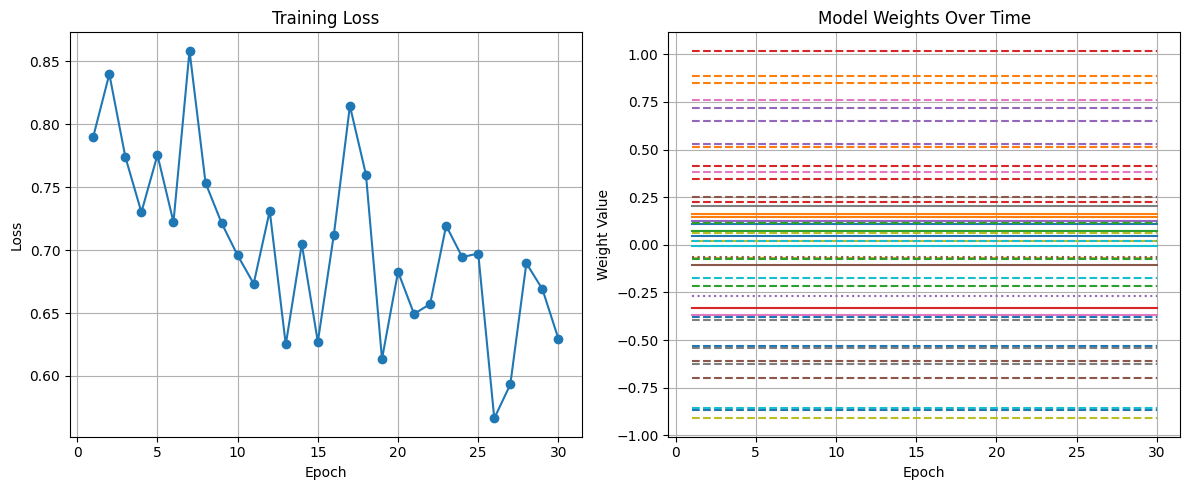

In [15]:
import matplotlib.pyplot as plt
def plot_training_results(results):
	epochs = range(1, len(results["loss"]) + 1)

	plt.figure(figsize=(12, 5))

	plt.subplot(1, 2, 1)
	plt.plot(epochs, results["loss"], marker='o')
	plt.title("Training Loss")
	plt.xlabel("Epoch")
	plt.ylabel("Loss")
	plt.grid()

	plt.subplot(1, 2, 2)
	for i in range(len(results["qnn_weights"][0])):
		qnn_weights_over_time = [weights[i] for weights in results["qnn_weights"]]
		plt.plot(epochs, qnn_weights_over_time, label=f"QNN Weight {i}")
	for i in range(len(results["head_weight"][0])):
		head_weights_over_time = [weights[i] for weights in results["head_weight"]]
		plt.plot(epochs, head_weights_over_time, label=f"Head Weight {i}", linestyle='--')
	for i in range(len(results["head_bias"][0])):
		head_bias_over_time = [bias[i] for bias in results["head_bias"]]
		plt.plot(epochs, head_bias_over_time, label=f"Head Bias {i}", linestyle=':')
	plt.title("Model Weights Over Time")
	plt.xlabel("Epoch")
	plt.ylabel("Weight Value")
	plt.grid()

	plt.tight_layout()
	plt.show()
plot_training_results(results)